# Лабораторная работа №1
## Тема: Модель лесного пожара (клеточный автомат)

**Выполнил:** Шелобанов Алексей, Снырёв Максим

## 1. Цель работы

Изучить принципы построения и работы клеточного автомата на примере модели лесного пожара.  
Исследовать динамику распространения огня и влияние параметров модели на поведение системы.

## 2. Задание

1. Реализовать клеточный автомат для модели лесного пожара.
2. Предусмотреть состояния клеток: пустая, дерево, огонь.
3. Реализовать правила перехода:
   - возгорание дерева при наличии не менее `k` горящих соседей;
   - случайное возгорание от молнии с вероятностью `f`;
   - выгорание горящего дерева;
   - рост нового дерева на пустой клетке с вероятностью `p`.
4. Провести моделирование при заданных параметрах.
5. Построить графики динамики числа деревьев, очагов огня и пустых клеток.
6. Визуализировать финальное состояние и анимацию процесса.
7. Сделать выводы.
Markdown-ячейка 3. Краткая теория
markdown

## 3. Краткие теоретические сведения

Модель лесного пожара — классический пример клеточного автомата.  
Поле представляется матрицей клеток, каждая из которых может находиться в одном из состояний:

- `0` — пустая клетка или сгоревшее дерево;
- `1` — клетка с деревом;
- `2` — горящее дерево.

На каждом такте все клетки обновляются синхронно по правилам:

1. Дерево загорается, если в его окрестности не меньше `k` горящих деревьев.
2. С вероятностью `f` дерево загорается от удара молнии.
3. Горящее дерево превращается в пустую клетку.
4. На месте пустой клетки с вероятностью `p` вырастает дерево, если рядом нет огня.

Окрестность может быть фон Неймана (4 соседа) или Мура (8 соседей).  
Граничные условия фиксированные: за границами поля деревьев нет.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.animation import FuncAnimation

# Состояния
EMPTY, TREE, FIRE = 0, 1, 2


def create_forest(size, density, rng):
    forest = np.zeros((size, size), dtype=np.int8)
    forest[rng.random((size, size)) < density] = TREE
    return forest


def _count_neighbors_moore(field, state):
    mask = (field == state).astype(np.int16)
    neighbors = np.zeros_like(mask, dtype=np.int16)
    for di in (-1, 0, 1):
        for dj in (-1, 0, 1):
            if di == 0 and dj == 0:
                continue
            shifted = np.roll(mask, shift=(di, dj), axis=(0, 1))
            if di == -1:
                shifted[-1, :] = 0
            elif di == 1:
                shifted[0, :] = 0
            if dj == -1:
                shifted[:, -1] = 0
            elif dj == 1:
                shifted[:, 0] = 0
            neighbors += shifted
    return neighbors


def count_neighbors(field, state, neighborhood):
    if neighborhood == "von_neumann":
        neighbors = np.zeros_like(field, dtype=np.int16)
        neighbors[1:, :]  += (field[:-1, :] == state)
        neighbors[:-1, :] += (field[1:, :]  == state)
        neighbors[:, 1:]  += (field[:, :-1] == state)
        neighbors[:, :-1] += (field[:, 1:]  == state)
        return neighbors
    elif neighborhood == "moore":
        return _count_neighbors_moore(field, state)
    raise ValueError(neighborhood)


def step(field, p, f, k, neighborhood, rng):
    size = field.shape[0]
    new_field = field.copy()

    fire_neighbors = count_neighbors(field, FIRE, neighborhood)

    ignition  = (field == TREE) & (fire_neighbors >= k)
    lightning = (field == TREE) & (rng.random((size, size)) < f)
    burning   = (field == FIRE)
    growth    = (field == EMPTY) & (fire_neighbors == 0) & \
                (rng.random((size, size)) < p)

    new_field[burning] = EMPTY
    new_field[ignition | lightning] = FIRE
    new_field[growth] = TREE
    return new_field


def run_simulation(size=100, steps=200, p=0.01, f=0.0001, k=1,
                   density=0.6, neighborhood="von_neumann",
                   seed=42, save_every=1):
    rng = np.random.default_rng(seed)
    field = create_forest(size, density, rng)

    history = {"trees": [], "fire": [], "empty": []}
    frames = []

    for t in range(steps):
        history["trees"].append(int(np.sum(field == TREE)))
        history["fire"].append(int(np.sum(field == FIRE)))
        history["empty"].append(int(np.sum(field == EMPTY)))
        if t % save_every == 0:
            frames.append(field.copy())
        field = step(field, p, f, k, neighborhood, rng)

    history["final_field"] = field
    history["frames"] = frames
    return history

## 4. Запуск модели и построение графиков

Зададим параметры:
- размер поля: `100 x 100`;
- число тактов: `200`;
- вероятность роста: `p = 0.01`;
- вероятность молнии: `f = 0.0001`;
- порог возгорания: `k = 1`;
- начальная плотность деревьев: `0.6`;
- окрестность: фон Неймана;
- генератор случайных чисел: `seed = 42`.

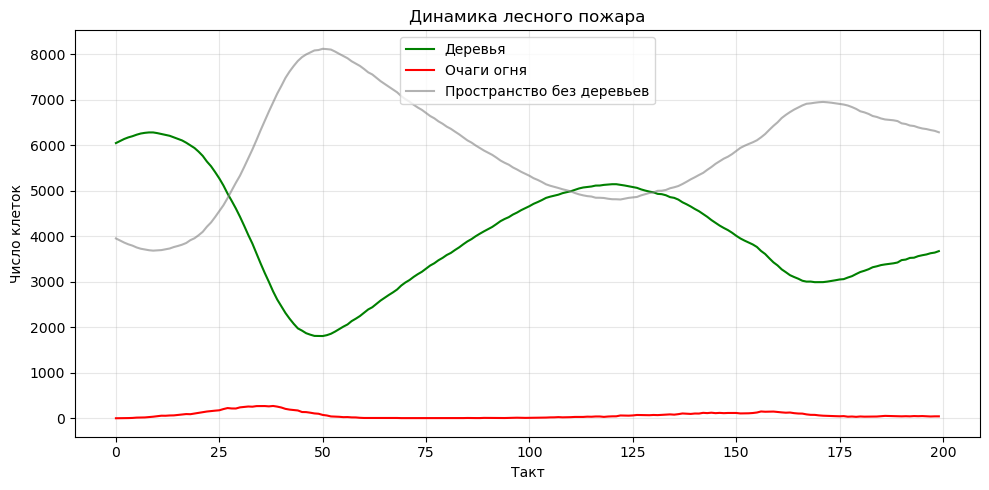

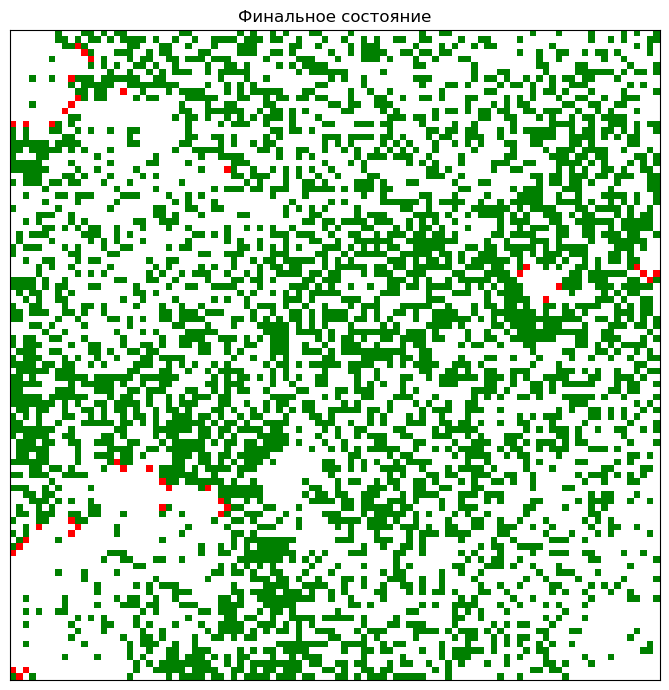

In [2]:
history = run_simulation(
    size=100, steps=200, p=0.01, f=0.0001, k=1,
    density=0.6, neighborhood="von_neumann", seed=42,
)

# --- График динамики ---
fig, ax = plt.subplots(figsize=(10, 5))
t = np.arange(len(history["trees"]))
ax.plot(t, history["trees"], label="Деревья", color="green")
ax.plot(t, history["fire"],  label="Очаги огня",   color="red")
ax.plot(t, history["empty"], label="Пространство без деревьев",  color="gray", alpha=0.6)
ax.set_xlabel("Такт"); ax.set_ylabel("Число клеток")
ax.set_title("Динамика лесного пожара"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# --- Финальное поле ---
cmap = ListedColormap(["white", "green", "red"])
fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(history["final_field"], cmap=cmap, vmin=0, vmax=2,
          interpolation="nearest")
ax.set_title("Финальное состояние"); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

## 5. Визуализация процесса в динамике

Построим анимацию, показывающую распространение пожара по тактам.

In [3]:
from matplotlib import rc
rc('animation', html='jshtml')  # чтобы анимация проигрывалась в ноутбуке

cmap = ListedColormap(["white", "green", "red"])
frames = history["frames"]

fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(frames[0], cmap=cmap, vmin=0, vmax=2, interpolation="nearest")
ax.set_xticks([]); ax.set_yticks([])
title = ax.set_title("Такт 0")

def update(i):
    im.set_data(frames[i])
    title.set_text(f"Такт {i}")
    return im, title

anim = FuncAnimation(fig, update, frames=len(frames), interval=80, blit=False)
plt.close(fig)
anim

## 6. Анализ результатов

В ходе моделирования можно наблюдать следующие эффекты:

1. В начальный момент времени большая часть клеток занята деревьями.
2. При появлении очага огня пожар распространяется по соседним клеткам.
3. Число деревьев резко падает, число пустых клеток растёт.
4. После затухания пожара начинается восстановление леса за счёт роста новых деревьев.
5. При малой вероятности молнии `f` и достаточной скорости роста `p` система может выходить на квазистационарный режим.
6. Изменение порога `k`, плотности `density` и окрестности влияет на скорость и характер распространения огня.

## 7. Вывод

В работе была реализована модель лесного пожара на основе клеточного автомата.  
Модель продемонстрировала типичные черты самоорганизованной критичности: распространение пожара, выгорание больших областей и последующее восстановление леса.  
Эксперимент показал, что динамика системы существенно зависит от параметров `p`, `f`, `k`, плотности деревьев и выбора окрестности.  
Полученные графики и анимация подтверждают работоспособность модели и её соответствие описанным правилам.